In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

In [3]:
true_mean = 180
true_std = 85
population_size = 3_000_000

population = np.random.normal(loc=true_mean, scale=true_std, size=population_size)

print(f"Population mean: {population.mean():.2f}")
print(f"Population standard deviation: {population.std():.2f}")
print(f"Population size: {len(population)}")


Population mean: 179.95
Population standard deviation: 85.04
Population size: 3000000


In [4]:
# Take samples of different sizes and calculate confidence intervals

sample_sizes = [50, 100, 300, 500, 1000, 3000]
results = []

for n in sample_sizes:
    sample = np.random.choice(population, size=n, replace=False)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    
    # Calculate 95% confidence interval
    ci = stats.t.interval(
        confidence=0.95,
        df=n-1,
        loc=sample_mean,
        scale=sample_std/np.sqrt(n)
    )
    
    results.append({
        "Sample Size": n,
        "Sample Mean": round(sample_mean, 2),
        "CI Lower": round(ci[0], 2),
        "CI Upper": round(ci[1], 2),
        "CI Width": round(ci[1] - ci[0], 2)
    })

df_results = pd.DataFrame(results)
df_results

,Sample Size,Sample Mean,CI Lower,CI Upper,CI Width
0,50,159.84,136.82,182.86,46.04
1,100,166.07,149.58,182.56,32.98
2,300,176.46,166.15,186.77,20.62
3,500,180.95,173.44,188.45,15.01
4,1000,180.06,174.79,185.34,10.55
5,3000,177.04,174.02,180.05,6.03


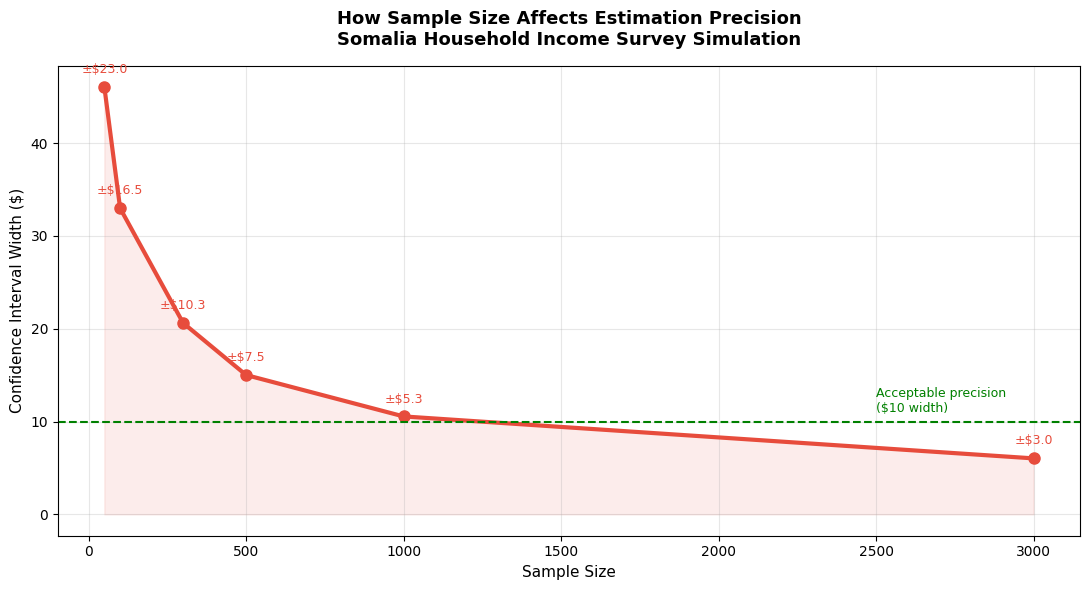

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(df_results["Sample Size"], df_results["CI Width"],
        color="#e74c3c", linewidth=3, marker="o", markersize=8)

ax.fill_between(df_results["Sample Size"],
                df_results["CI Width"], 0,
                alpha=0.1, color="#e74c3c")

for _, row in df_results.iterrows():
    ax.annotate(f"±${row['CI Width']/2:.1f}",
                xy=(row["Sample Size"], row["CI Width"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=9, color="#e74c3c")

ax.axhline(y=10, color="green", linestyle="--", linewidth=1.5)
ax.text(2500, 11, "Acceptable precision\n($10 width)", 
        fontsize=9, color="green")

ax.set_xlabel("Sample Size", fontsize=11)
ax.set_ylabel("Confidence Interval Width ($)", fontsize=11)
ax.set_title("How Sample Size Affects Estimation Precision\n"
             "Somalia Household Income Survey Simulation",
             fontsize=13, fontweight="bold", pad=15)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figure1_sample_size_vs_ci.jpg", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
df = pd.read_csv(r'C:\Users\abdin\Desktop\Decision Analysist\Chapter 1 Projects\East African Countries Development Indicators\Data\EAC_Development_Indicators_Clean.csv')

# Extract Kenya GDP per capita
kenya_gdp = df[
    (df["Country Name"] == "Kenya") & 
    (df["Series Name"] == "GDP per capita (current LCU)")
]["Value"].dropna()

print(f"Number of observations: {len(kenya_gdp)}")
print(f"Mean GDP per capita: {kenya_gdp.mean():,.2f}")
print(f"Standard deviation: {kenya_gdp.std():,.2f}")

Number of observations: 15
Mean GDP per capita: 176,151.31
Standard deviation: 63,414.22


In [7]:
# Calculate 95% confidence interval for Kenya GDP per capita
n = len(kenya_gdp)
mean = kenya_gdp.mean()
std = kenya_gdp.std()

ci = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=mean,
    scale=std/np.sqrt(n)
)

print(f"Sample size: {n}")
print(f"Mean: {mean:,.2f} KES")
print(f"95% CI: ({ci[0]:,.2f}, {ci[1]:,.2f}) KES")
print(f"CI Width: {ci[1]-ci[0]:,.2f} KES")

Sample size: 15
Mean: 176,151.31 KES
95% CI: (141,033.69, 211,268.94) KES
CI Width: 70,235.25 KES
